# Test: StructureAutoencoder Module

Validates the `StructureAutoencoder` and `geometry` utilities.
**No ESM / full MiniFold loading** — uses precomputed embeddings and `from_checkpoint`.

1. Load AE from checkpoint (~62M params, no ESM needed)
2. Test `coords_to_distogram` against reference
3. Test encode: atom37 → z
4. Test decode: z → atom37 via StructureModule
5. Full round-trip: encode → decode → compare with ground truth
6. Batched inference via DataLoader

In [1]:
## Cell 1: Setup — dataset + StructureAutoencoder (lightweight, no ESM)

import torch
from pathlib import Path

from mini_latent_pd.data import MDCathToMinifoldDataset, mdcath_collate, BucketBatchSampler
from mini_latent_pd.models.structure_autoencoder import StructureAutoencoder
from mini_latent_pd.utils.geometry import (
    pseudo_beta_from_atom37,
    coords_to_distogram,
    kabsch_align,
    kabsch_rmsd,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Dataset with precomputed embeddings
LOCAL_DIR = Path("../data/mdcath")
EMB_DIR = Path("../data/embeddings")

ds = MDCathToMinifoldDataset(
    data_dir=LOCAL_DIR / "data",
    embedding_dir=EMB_DIR,
    samples_per_epoch=10,
    max_seq_len=900,
)
print(f"Dataset: {len(ds.proteins)} proteins, {len(ds)} samples/epoch")

# Load StructureAutoencoder directly from checkpoint (~62M params, no ESM)
CKPT = Path("../checkpoints/minifold_cache/minifold_12L.ckpt")
ae = StructureAutoencoder.from_checkpoint(str(CKPT), device=str(device))
ae.eval()
print(f"AE parameters: {sum(p.numel() for p in ae.parameters()):,}")

Device: mps
  Indexed 12asA00: L=327, 11100 frames, seq=AYIAKQRQISFVKSXFSRQL..., emb=✓
  Indexed 153lA00: L=185, 11140 frames, seq=RTDCYGNVNRIDTTGASCKT..., emb=✓
  Indexed 16pkA02: L=208, 11110 frames, seq=YFAKVLGNPPRPLVAIVGGA..., emb=✓
  Indexed 1a02F00: L=53, 10980 frames, seq=RRIRRERNKMAAAKSRNRRR..., emb=✓
  Indexed 1a05A00: L=357, 11000 frames, seq=MKKIAIFAGDGIGPEIVAAA..., emb=✓
  Indexed 1a0aA00: L=63, 10990 frames, seq=MKRESXKXAEQARRNRLAVA..., emb=✓
  Indexed 1a0hA01: L=89, 11030 frames, seq=SPLLETCVPDRGREYRGRLA..., emb=✓
  Indexed 1a0rP01: L=129, 11010 frames, seq=CMQDMXQKLSFGPRYGFVYE..., emb=✓
  Indexed 1a0sP00: L=413, 10970 frames, seq=SGFEFXGYARSGVIMNDSGA..., emb=✓
  Indexed 1a15A00: L=67, 11090 frames, seq=KPVSLSYRCPCRFFESXVAR..., emb=✓
  Indexed 1a1zA00: L=83, 11040 frames, seq=MDPFLVLLXSVSSSLSSSEL..., emb=✓
  Indexed 1a2nA02: L=208, 11060 frames, seq=AKNAALPILFAALLAEEPVE..., emb=✓
  Indexed 1a39A00: L=401, 10981 frames, seq=KPGETKEVXPQLTTFRCTKR..., emb=✓
  Indexed 1a3dA00:

In [2]:
## Cell 2: Test coords_to_distogram consistency

from mini_latent_pd.models.minifold.utils.tensor_utils import pts_to_distogram

sample = ds[0]
x0 = sample["x0"].unsqueeze(0)
aatype = sample["aatype"].unsqueeze(0)

dgram = coords_to_distogram(x0, aatype)

# Reference
pb = pseudo_beta_from_atom37(x0, aatype)
ref_bins = pts_to_distogram(pb)
our_bins = dgram.argmax(dim=-1)

match = (ref_bins == our_bins).float().mean()
print(f"Protein: {sample['id']}, L={len(sample['sequence'])}")
print(f"Distogram shape: {dgram.shape}")
print(f"Consistency with pts_to_distogram: {match:.4f}")
assert match == 1.0, f"Mismatch! Only {match:.4f} bins agree"
print("PASS: coords_to_distogram matches reference")

Protein: 153lA00, L=185
Distogram shape: torch.Size([1, 185, 185, 64])
Consistency with pts_to_distogram: 1.0000
PASS: coords_to_distogram matches reference


In [3]:
## Cell 3: Test encode — atom37 → z  (uses precomputed s_s, s_z from dataset)

sample = ds[0]
L = len(sample["sequence"])

s_s = sample["s_s"].unsqueeze(0).to(device)       # (1, L, 1024)
s_z = sample["s_z"].unsqueeze(0).to(device)       # (1, L, L, 128)
x0_dev = sample["x0"].unsqueeze(0).to(device)     # (1, L, 37, 3)
aatype_dev = sample["aatype"].unsqueeze(0).to(device).long()
seq_mask = torch.ones(1, L, dtype=torch.float32, device=device)

print(f"Inputs — s_s: {s_s.shape}, s_z: {s_z.shape}, x0: {x0_dev.shape}")

with torch.no_grad():
    z = ae.encode(x0_dev, s_s, s_z, aatype_dev, seq_mask)

print(f"Encoded z: {z.shape}")
print(f"  mean={z.mean():.4f}, std={z.std():.4f}")
print("PASS: encode works")

Inputs — s_s: torch.Size([1, 53, 1024]), s_z: torch.Size([1, 53, 53, 128]), x0: torch.Size([1, 53, 37, 3])
Encoded z: torch.Size([1, 53, 53, 128])
  mean=-0.0608, std=9.6443
PASS: encode works


In [4]:
## Cell 4: Test decode — z → atom37

with torch.no_grad():
    dec_out = ae.decode(z, s_s, aatype_dev, seq_mask)

pred_atom37 = dec_out["atom37_pos"]
atom37_mask = dec_out["atom37_mask"]

print(f"Decoded atom37: {pred_atom37.shape}")
print(f"atom37_mask: {atom37_mask.shape}, avg atoms/res: {atom37_mask.sum(-1).mean():.1f}")
print("PASS: decode works")

Decoded atom37: torch.Size([1, 53, 37, 3])
atom37_mask: torch.Size([1, 53, 37]), avg atoms/res: 8.3
PASS: decode works


/Users/moustholmes/mini_latent_pd/src/mini_latent_pd/models/minifold/utils/tensor_utils.py:86: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


In [5]:
## Cell 5: Full round-trip — encode → decode → compare with GT

import numpy as np

with torch.no_grad():
    out = ae(x0_dev, s_s, s_z, aatype_dev, seq_mask)

pred_a37 = out["atom37_pos"]
gt_a37 = x0_dev
gt_mask = sample["atom37_mask"].unsqueeze(0).to(device)
valid = (out["atom37_mask"] * gt_mask).bool()

diff = (pred_a37 - gt_a37)[valid]
per_atom_dist = diff.norm(dim=-1)

CA_IDX = 1
ca_pred = pred_a37[:, :, CA_IDX, :]
ca_gt = gt_a37[:, :, CA_IDX, :]
ca_rmsd_val = kabsch_rmsd(ca_pred[0], ca_gt[0])

print(f"=== Round-trip — {sample['id']} (L={L}) ===")
print(f"  Valid atoms: {valid.sum().item()}")
print(f"  All-atom RMSD: {per_atom_dist.pow(2).mean().sqrt():.2f} A")
print(f"  All-atom MAE:  {per_atom_dist.mean():.2f} A")
print(f"  Ca RMSD (Kabsch): {ca_rmsd_val:.2f} A")
print("PASS: full round-trip (high RMSD expected — no fine-tuning yet)")

=== Round-trip — 1a02F00 (L=53) ===
  Valid atoms: 442
  All-atom RMSD: 101.02 A
  All-atom MAE:  100.17 A
  Ca RMSD (Kabsch): 14.44 A
PASS: full round-trip (high RMSD expected — no fine-tuning yet)


/Users/moustholmes/mini_latent_pd/src/mini_latent_pd/utils/geometry.py:119: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, _, Vt = torch.linalg.svd(H)


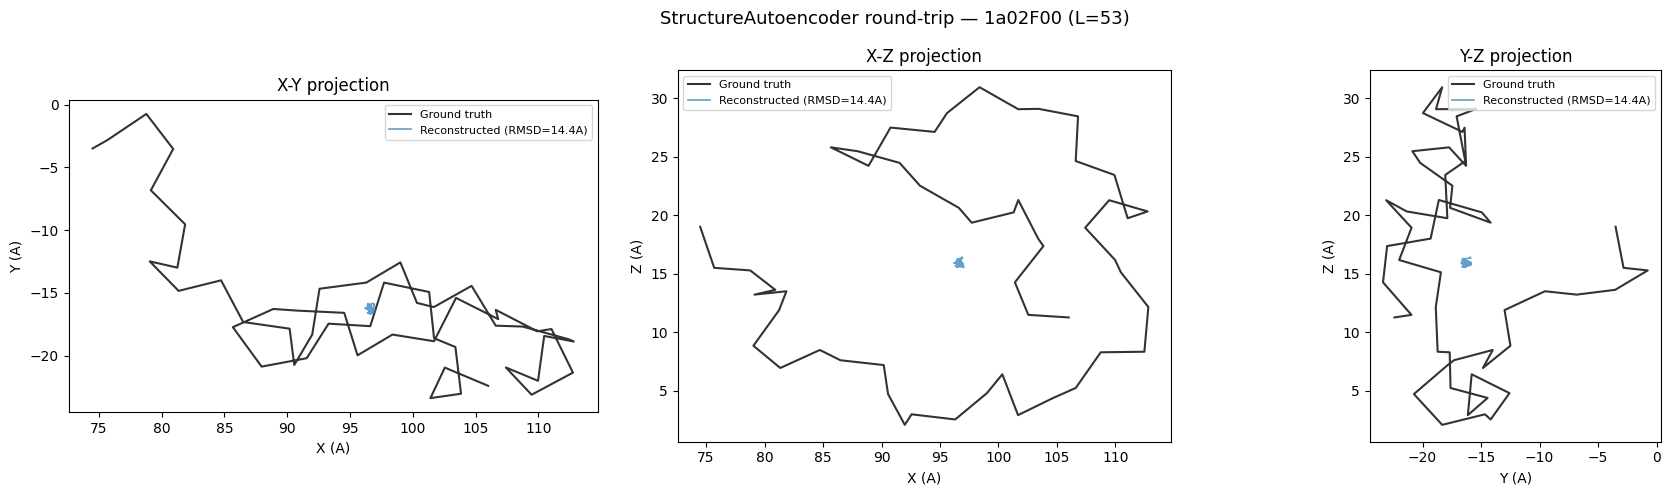

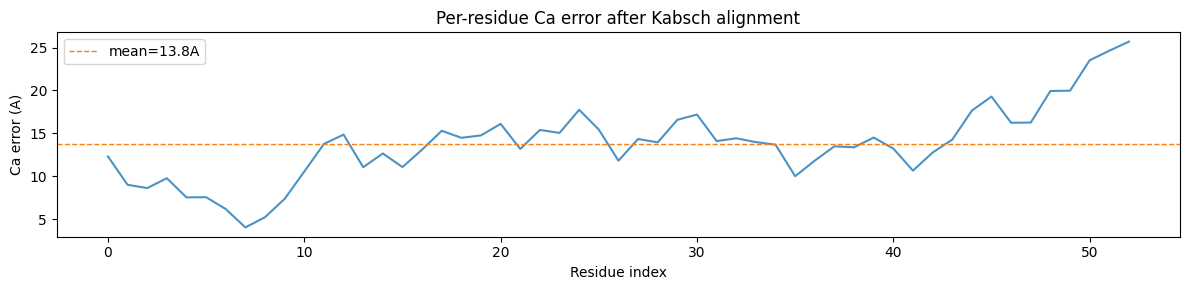

In [6]:
## Cell 6: Visualise Ca traces — ground truth vs reconstruction

import matplotlib.pyplot as plt

ca_gt_np = ca_gt[0].cpu().numpy()
ca_pred_np = kabsch_align(ca_pred[0].cpu().numpy(), ca_gt_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
projections = [("X", "Y", 0, 1), ("X", "Z", 0, 2), ("Y", "Z", 1, 2)]
for ax, (xl, yl, i, j) in zip(axes, projections):
    ax.plot(ca_gt_np[:, i], ca_gt_np[:, j], '-', color='black', lw=1.5, label='Ground truth', alpha=0.8)
    ax.plot(ca_pred_np[:, i], ca_pred_np[:, j], '-', color='tab:blue', lw=1.2,
            label=f'Reconstructed (RMSD={ca_rmsd_val:.1f}A)', alpha=0.7)
    ax.set_xlabel(f'{xl} (A)'); ax.set_ylabel(f'{yl} (A)')
    ax.legend(fontsize=8); ax.set_aspect('equal')
    ax.set_title(f'{xl}-{yl} projection')

fig.suptitle(f'StructureAutoencoder round-trip — {sample["id"]} (L={L})', fontsize=13)
plt.tight_layout()
plt.show()

# Per-residue error
ca_err = np.linalg.norm(ca_pred_np - ca_gt_np, axis=-1)
fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.plot(ca_err, color='tab:blue', alpha=0.8)
ax2.axhline(y=ca_err.mean(), color='tab:orange', ls='--', lw=1, label=f'mean={ca_err.mean():.1f}A')
ax2.set_xlabel('Residue index'); ax2.set_ylabel('Ca error (A)')
ax2.set_title('Per-residue Ca error after Kabsch alignment')
ax2.legend()
plt.tight_layout()
plt.show()

In [7]:
## Cell 7: Batched round-trip via DataLoader (with precomputed embeddings)

from torch.utils.data import DataLoader

lengths = [p["n_residues"] for p in ds.proteins]
sampler = BucketBatchSampler(lengths=lengths, batch_size=2, shuffle=False)
loader = DataLoader(ds, batch_sampler=sampler, collate_fn=mdcath_collate, num_workers=0)

print(f"DataLoader: {len(loader)} batches")

for batch_idx, batch in enumerate(loader):
    B = batch["x0"].shape[0]
    seq_mask = batch["seq_mask"].to(device)
    x0_dev = batch["x0"].to(device)
    aatype_dev = batch["aatype"].to(device).long()
    s_s_b = batch["s_s"].to(device)
    s_z_b = batch["s_z"].to(device)

    with torch.no_grad():
        out = ae(x0_dev, s_s_b, s_z_b, aatype_dev, seq_mask)

    gt_a37 = x0_dev
    for i in range(B):
        L_i = int(seq_mask[i].sum().item())
        ca_p = out["atom37_pos"][i, :L_i, 1, :]
        ca_g = gt_a37[i, :L_i, 1, :]
        rmsd = kabsch_rmsd(ca_p, ca_g)
        print(f"  batch {batch_idx}, sample {i}: L={L_i}, Ca RMSD={rmsd:.2f} A")

    if batch_idx >= 2:
        print(f"  ... ({len(loader)} total batches)")
        break

print("\nPASS: batched inference works")

DataLoader: 10 batches
  batch 0, sample 0: L=327, Ca RMSD=20.13 A
  batch 0, sample 1: L=357, Ca RMSD=21.07 A
  batch 1, sample 0: L=129, Ca RMSD=15.05 A
  batch 2, sample 0: L=129, Ca RMSD=14.20 A
  batch 2, sample 1: L=342, Ca RMSD=20.14 A
  ... (10 total batches)

PASS: batched inference works


In [8]:
## Cell 8: Weight-loading verification
# Verify from_checkpoint loaded weights correctly by comparing with raw checkpoint tensors.

raw = torch.load(str(CKPT), map_location="cpu", weights_only=False)["state_dict"]
raw = {k.replace("_orig_mod.", ""): v for k, v in raw.items()
       if "boundaries" not in k and "mid_points" not in k}
ae_sd = ae.state_dict()

from mini_latent_pd.models.structure_autoencoder import StructureAutoencoder
KEY_MAP = StructureAutoencoder._CKPT_KEY_MAP

mismatched, checked, unmapped = [], 0, 0
for ae_key, ae_val in ae_sd.items():
    for ae_prefix, ckpt_prefix in KEY_MAP.items():
        if ae_key.startswith(ae_prefix):
            ckpt_key = ckpt_prefix + ae_key[len(ae_prefix):]
            break
    else:
        unmapped += 1
        continue

    if ckpt_key not in raw:
        unmapped += 1
        continue

    if not torch.equal(ae_val.cpu(), raw[ckpt_key].cpu()):
        mismatched.append(ae_key)
    checked += 1

print(f"Compared {checked}/{len(ae_sd)} parameters ({unmapped} unmapped)")
if mismatched:
    print(f"FAIL: {len(mismatched)} mismatched: {mismatched[:5]}")
else:
    print("PASS: all AE weights match checkpoint exactly")

Compared 147/147 parameters (0 unmapped)
PASS: all AE weights match checkpoint exactly


# Diagnostic: Why is the reconstruction compressed?

Systematic checks:
1. **Ground truth sanity** — are the input coords actually spread out?
2. **Encode sanity** — is z informative or degenerate?
3. **pair_to_seq output** — is the single repr `s` after projection degenerate?
4. **StructureModule internals** — are bb_update predictions (N/Ca/C) collapsed?
5. **Scale factor** — does `trans_scale_factor` match training?
6. **Buffer check** — did StructureModule buffers (default_frames etc.) load correctly?
7. **Uninformed baseline** — is encode even helping vs random z?

In [9]:
## Diag 1: Ground truth sanity — are the input coords spread out?

sample = ds[0]
x0_gt = sample["x0"]  # (L, 37, 3)
L = len(sample["sequence"])
ca_gt_raw = x0_gt[:, 1, :]  # Cα = atom index 1

print(f"Protein: {sample['id']}, L={L}")
print(f"\nGround truth Cα coords:")
print(f"  shape: {ca_gt_raw.shape}")
print(f"  min:  {ca_gt_raw.min(0).values.tolist()}")
print(f"  max:  {ca_gt_raw.max(0).values.tolist()}")
print(f"  mean: {ca_gt_raw.mean(0).tolist()}")
print(f"  span: {(ca_gt_raw.max(0).values - ca_gt_raw.min(0).values).tolist()}")
print(f"  Cα pairwise dist — min: {torch.cdist(ca_gt_raw.unsqueeze(0), ca_gt_raw.unsqueeze(0))[0].fill_diagonal_(999).min():.2f} Å")
print(f"  Cα pairwise dist — max: {torch.cdist(ca_gt_raw.unsqueeze(0), ca_gt_raw.unsqueeze(0))[0].max():.2f} Å")

print(f"\nGround truth atom37 overall:")
print(f"  all-zero atom count: {(x0_gt.abs().sum(-1) == 0).sum().item()}")
print(f"  non-zero atom count: {(x0_gt.abs().sum(-1) != 0).sum().item()}")
print(f"  atom37 coord range: [{x0_gt[x0_gt.abs().sum(-1) != 0].min():.2f}, {x0_gt[x0_gt.abs().sum(-1) != 0].max():.2f}]")

Protein: 1a0aA00, L=63

Ground truth Cα coords:
  shape: torch.Size([63, 3])
  min:  [59.83000183105469, 43.15999984741211, 17.34000015258789]
  max:  [88.83000183105469, 63.090003967285156, 40.69000244140625]
  mean: [72.44429016113281, 54.51667022705078, 28.87000274658203]
  span: [29.0, 19.930004119873047, 23.35000228881836]
  Cα pairwise dist — min: 3.75 Å
  Cα pairwise dist — max: 29.60 Å

Ground truth atom37 overall:
  all-zero atom count: 1834
  non-zero atom count: 497
  atom37 coord range: [11.73, 92.79]


In [10]:
## Diag 2: Encode sanity — is z informative or degenerate?

x0_dev = sample["x0"].unsqueeze(0).to(device)
aatype_dev = sample["aatype"].unsqueeze(0).to(device).long()
s_s = sample["s_s"].unsqueeze(0).to(device)
s_z = sample["s_z"].unsqueeze(0).to(device)
seq_mask = torch.ones(1, L, dtype=torch.float32, device=device)

with torch.no_grad():
    z = ae.encode(x0_dev, s_s, s_z, aatype_dev, seq_mask)

print(f"z shape: {z.shape}")
print(f"z stats: mean={z.mean():.4f}, std={z.std():.4f}, min={z.min():.4f}, max={z.max():.4f}")
print(f"z has NaN: {z.isnan().any().item()}, Inf: {z.isinf().any().item()}")

# Check each component separately
pair_mask = seq_mask[:, None, :] * seq_mask[:, :, None]
residx = torch.arange(L, device=device).unsqueeze(0)

with torch.no_grad():
    s2p = ae.seq_to_pair(s_s)
    rp = ae.rel_pos(residx, mask=pair_mask)
    s_z_cat = torch.cat([s_z, s2p, rp], dim=-1)
    s_z_static = ae.proj(s_z_cat)
    disto = coords_to_distogram(x0_dev, aatype_dev)
    recycle_contrib = ae.recycle(disto)

print(f"\nEncoder component breakdown:")
print(f"  s_z (ESM pair):       mean={s_z.mean():.4f}, std={s_z.std():.4f}")
print(f"  seq_to_pair output:   mean={s2p.mean():.4f}, std={s2p.std():.4f}")
print(f"  rel_pos output:       mean={rp.mean():.4f}, std={rp.std():.4f}")
print(f"  s_z_static (proj):    mean={s_z_static.mean():.4f}, std={s_z_static.std():.4f}")
print(f"  recycle(disto):       mean={recycle_contrib.mean():.4f}, std={recycle_contrib.std():.4f}")
print(f"  final z:              mean={z.mean():.4f}, std={z.std():.4f}")
print(f"\n  recycle/static ratio: {recycle_contrib.std() / s_z_static.std():.4f}")

z shape: torch.Size([1, 63, 63, 128])
z stats: mean=-0.0793, std=10.1110, min=-120.5901, max=51.4890
z has NaN: False, Inf: False

Encoder component breakdown:
  s_z (ESM pair):       mean=-0.0124, std=0.6634
  seq_to_pair output:   mean=0.0083, std=0.7898
  rel_pos output:       mean=-0.0221, std=0.3719
  s_z_static (proj):    mean=-0.0528, std=9.4889
  recycle(disto):       mean=-0.0265, std=1.0135
  final z:              mean=-0.0793, std=10.1110

  recycle/static ratio: 0.1068


In [11]:
## Diag 3: pair_to_seq output — is the single repr degenerate?

with torch.no_grad():
    single = ae.pair_to_seq(z, s_s, pair_mask)

print(f"pair_to_seq output (single repr):")
print(f"  shape: {single.shape}")
print(f"  mean={single.mean():.4f}, std={single.std():.4f}")
print(f"  min={single.min():.4f}, max={single.max():.4f}")
print(f"  has NaN: {single.isnan().any().item()}, Inf: {single.isinf().any().item()}")
print(f"  fraction near zero (<1e-6): {(single.abs() < 1e-6).float().mean():.4f}")

# Compare with input s_s
print(f"\nInput s_s for reference:")
print(f"  mean={s_s.mean():.4f}, std={s_s.std():.4f}")
print(f"  min={s_s.min():.4f}, max={s_s.max():.4f}")

# Check if pair_to_seq is just returning s_s (passthrough)
cos_sim = torch.nn.functional.cosine_similarity(single.flatten(), s_s.flatten(), dim=0)
print(f"\n  cosine similarity (single vs s_s): {cos_sim:.4f}")

pair_to_seq output (single repr):
  shape: torch.Size([1, 63, 1024])
  mean=49.3103, std=2669.3718
  min=-63121.1523, max=40621.1914
  has NaN: False, Inf: False
  fraction near zero (<1e-6): 0.0000

Input s_s for reference:
  mean=2.4581, std=376.8165
  min=-5458.6870, max=5456.2539

  cosine similarity (single vs s_s): -0.0699


In [13]:
## Diag 4: StructureModule internals — are bb_update (N/Ca/C) predictions collapsed?

from mini_latent_pd.models.minifold.utils.tensor_utils import permute_final_dims

sm = ae.structure_module

with torch.no_grad():
    # Replicate what decode does
    single_in = ae.pair_to_seq(z, s_s, pair_mask)

    # Run SM forward manually to inspect
    s_ln = sm.layer_norm_s(single_in)
    s_init = s_ln.clone()
    s_proc = sm.linear_in(s_ln)

    # Pairwise bias
    z_ln = sm.layer_norm_z(z)
    b = sm.linear_b(z_ln)
    b = permute_final_dims(b, (2, 0, 1))
    b = b.reshape(1, sm.no_blocks, sm.no_heads, L, L)

    # Run transformer blocks
    for i in range(sm.no_blocks):
        s_proc = s_proc + sm.attn[i](s_proc, b[:, i], seq_mask)
        s_proc = s_proc + sm.transitions[i](s_proc)

    # Get bb_update predictions (the critical step)
    bb_raw = sm.bb_update(s_proc.float())  # (B, L, 9)

    # Split into N, Ca, C
    n_pos, ca_pos, c_pos = bb_raw.chunk(3, dim=-1)  # each (B, L, 3)

print(f"bb_update raw output (before make_transform_from_reference):")
print(f"  shape: {bb_raw.shape}")
print(f"  mean={bb_raw.mean():.6f}, std={bb_raw.std():.6f}")
print(f"  min={bb_raw.min():.6f}, max={bb_raw.max():.6f}")
print(f"\nPredicted N positions:  mean={n_pos.mean():.4f}, std={n_pos.std():.4f}, range=[{n_pos.min():.4f}, {n_pos.max():.4f}]")
print(f"Predicted Ca positions: mean={ca_pos.mean():.4f}, std={ca_pos.std():.4f}, range=[{ca_pos.min():.4f}, {ca_pos.max():.4f}]")
print(f"Predicted C positions:  mean={c_pos.mean():.4f}, std={c_pos.std():.4f}, range=[{c_pos.min():.4f}, {c_pos.max():.4f}]")

# After scale factor
print(f"\ntrans_scale_factor = {sm.trans_scale_factor}")
print(f"Predicted Ca * scale_factor: range=[{ca_pos.min() * sm.trans_scale_factor:.4f}, {ca_pos.max() * sm.trans_scale_factor:.4f}]")
print(f"Predicted Ca * scale_factor: span={((ca_pos.max(1).values - ca_pos.min(1).values) * sm.trans_scale_factor).tolist()}")

# For reference, what should the Cα span be?
gt_ca = x0_dev[:, :, 1, :]
print(f"\nGround truth Cα span: {(gt_ca.max(1).values - gt_ca.min(1).values).tolist()}")

bb_update raw output (before make_transform_from_reference):
  shape: torch.Size([1, 63, 9])
  mean=0.204212, std=2.103285
  min=-7.050093, max=7.421978

Predicted N positions:  mean=-0.9285, std=2.5263, range=[-7.0501, 5.8845]
Predicted Ca positions: mean=0.2785, std=0.5366, range=[-0.3841, 1.0500]
Predicted C positions:  mean=1.2626, std=2.0560, range=[-3.5583, 7.4220]

trans_scale_factor = 10
Predicted Ca * scale_factor: range=[-3.8413, 10.5000]
Predicted Ca * scale_factor: span=[[1.7235345840454102, 1.423972249031067, 1.3384991884231567]]

Ground truth Cα span: [[29.0, 19.930004119873047, 23.35000228881836]]


In [14]:
## Diag 5: Buffer check — did StructureModule buffers load correctly?

print("StructureModule buffers:")
for name, buf in sm.named_buffers():
    print(f"  {name}: shape={buf.shape}, dtype={buf.dtype}, "
          f"min={buf.min():.4f}, max={buf.max():.4f}, "
          f"all_zero={bool((buf == 0).all())}")

# Check if default_frames looks right (should have non-trivial rotation matrices)
df = sm.default_frames
print(f"\ndefault_frames shape: {df.shape}")
print(f"  sample [ALA, backbone frame]:\n  {df[0, 0]}")  # Should be identity-like 4x4
print(f"  sample [ALA, chi1 frame]:\n  {df[0, 4]}")  # Should have rotation

# Check atom_mask
am = sm.atom_mask
print(f"\natom_mask shape: {am.shape}")
print(f"  ALA mask: {am[0].tolist()}")  # ALA has 5 atoms: N, CA, C, O, CB
print(f"  GLY mask: {am[5].tolist()}")  # GLY has 4 atoms: N, CA, C, O

StructureModule buffers:
  default_frames: shape=torch.Size([21, 8, 4, 4]), dtype=torch.float32, min=-1.2930, max=1.6950, all_zero=False
  group_idx: shape=torch.Size([21, 14]), dtype=torch.int64, min=0.0000, max=7.0000, all_zero=False
  atom_mask: shape=torch.Size([21, 14]), dtype=torch.float32, min=0.0000, max=1.0000, all_zero=False
  lit_positions: shape=torch.Size([21, 14, 3]), dtype=torch.float32, min=-3.3890, max=4.1680, all_zero=False

default_frames shape: torch.Size([21, 8, 4, 4])
  sample [ALA, backbone frame]:
  tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], device='mps:0')
  sample [ALA, chi1 frame]:
  tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], device='mps:0')

atom_mask shape: torch.Size([21, 14])
  ALA mask: [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  GLY mask: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0,

In [15]:
## Diag 6: Predicted atom14/atom37 coordinate analysis

with torch.no_grad():
    out = ae(x0_dev, s_s, s_z, aatype_dev, seq_mask)

pred_a14 = out["atom14_pos"]   # (B, L, 14, 3)
pred_a37 = out["atom37_pos"]   # (B, L, 37, 3)
gt_a37 = x0_dev

# Compare coordinate ranges
print("=== Coordinate range comparison ===")
print(f"{'':>25} {'min':>10} {'max':>10} {'mean':>10} {'std':>10}")

gt_ca = gt_a37[0, :, 1, :]
pred_ca = pred_a37[0, :, 1, :]
for label, ca in [("GT Cα", gt_ca), ("Pred Cα", pred_ca)]:
    for dim, ax in enumerate(["x", "y", "z"]):
        vals = ca[:, dim]
        print(f"  {label} {ax}: {vals.min():>10.2f} {vals.max():>10.2f} {vals.mean():>10.2f} {vals.std():>10.2f}")
    print()

# Are ALL atoms collapsed or just some?
nonzero_pred = pred_a37[0][pred_a37[0].abs().sum(-1) > 0]
nonzero_gt = gt_a37[0][gt_a37[0].abs().sum(-1) > 0]
print(f"Pred non-zero atoms: {len(nonzero_pred)}, coord range: [{nonzero_pred.min():.2f}, {nonzero_pred.max():.2f}]")
print(f"GT   non-zero atoms: {len(nonzero_gt)}, coord range: [{nonzero_gt.min():.2f}, {nonzero_gt.max():.2f}]")

# Centroid comparison
print(f"\nPred Cα centroid: {pred_ca.mean(0).tolist()}")
print(f"GT   Cα centroid: {gt_ca.mean(0).tolist()}")

# atom14 check
pred_a14_ca = pred_a14[0, :, 1, :]  # atom14 index 1 = CA
print(f"\natom14 Cα range: [{pred_a14_ca.min():.2f}, {pred_a14_ca.max():.2f}]")
print(f"atom14 Cα std per dim: {pred_a14_ca.std(0).tolist()}")

=== Coordinate range comparison ===
                                 min        max       mean        std
  GT Cα x:      59.83      88.83      72.44       7.48
  GT Cα y:      43.16      63.09      54.52       4.88
  GT Cα z:      17.34      40.69      28.87       5.81

  Pred Cα x:       0.00       2.62       1.53       0.55
  Pred Cα y:       0.00      10.50       9.20       2.43
  Pred Cα z:      -3.84      -0.00      -2.90       0.82

Pred non-zero atoms: 457, coord range: [-9.98, 16.93]
GT   non-zero atoms: 497, coord range: [11.73, 92.79]

Pred Cα centroid: [1.5317375659942627, 9.203487396240234, -2.903625011444092]
GT   Cα centroid: [72.44429016113281, 54.51667022705078, 28.87000274658203]

atom14 Cα range: [-3.84, 10.50]
atom14 Cα std per dim: [0.5495483875274658, 2.4338436126708984, 0.8218810558319092]


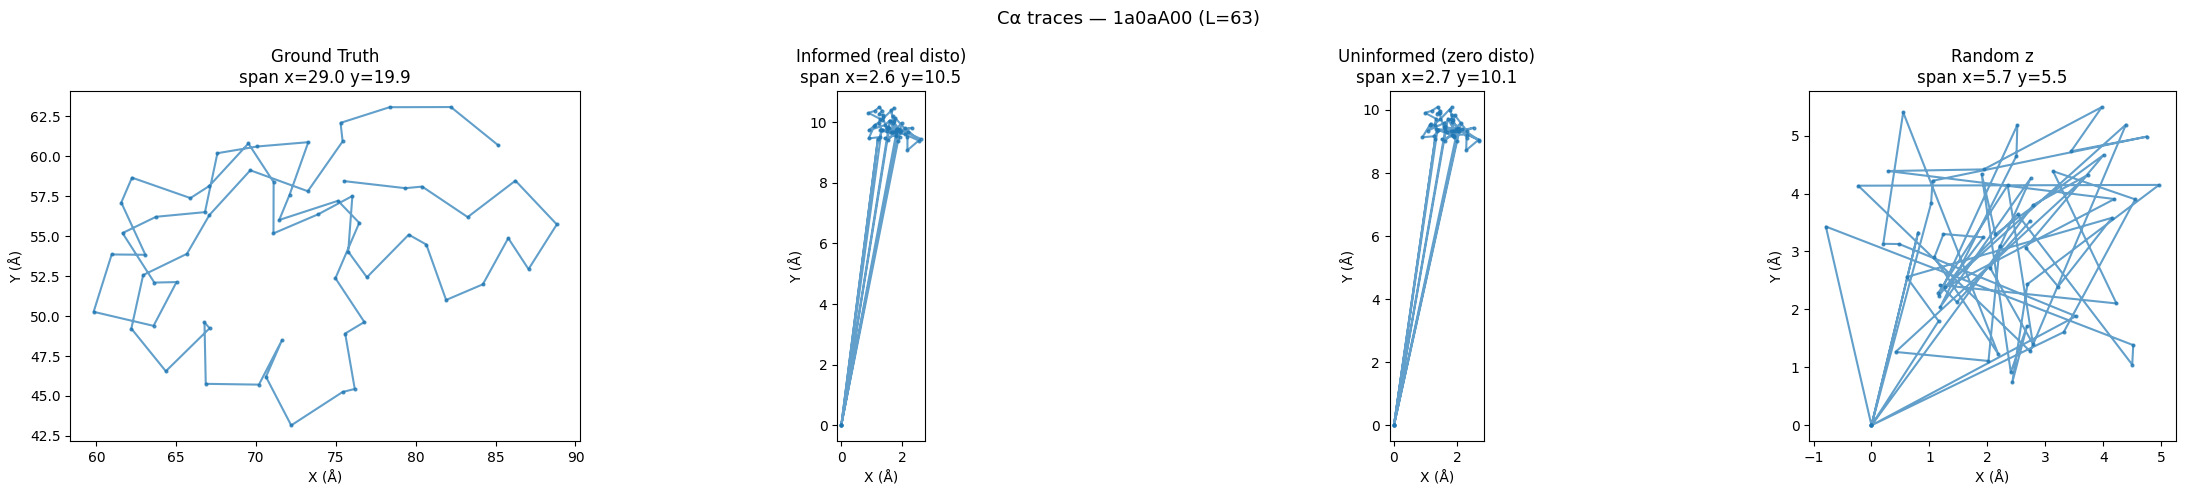

            GT: span = [29.0, 19.9, 23.4] Å
      Informed: span = [2.6, 10.5, 3.8] Å
    Uninformed: span = [2.7, 10.1, 3.9] Å
        Random: span = [5.7, 5.5, 4.5] Å


In [17]:
## Diag 7: Uninformed baseline vs informed — is the encode helping at all?

import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    # Informed z (with real distogram)
    z_informed = ae.encode(x0_dev, s_s, s_z, aatype_dev, seq_mask)
    out_informed = ae.decode(z_informed, s_s, aatype_dev, seq_mask)

    # Uninformed z (zero distogram — just static pair features)
    zero_disto = torch.zeros_like(coords_to_distogram(x0_dev, aatype_dev))
    pair_mask = seq_mask[:, None, :] * seq_mask[:, :, None]
    residx = torch.arange(L, device=device).unsqueeze(0)
    s_z_cat = torch.cat([s_z, ae.seq_to_pair(s_s), ae.rel_pos(residx, mask=pair_mask)], dim=-1)
    z_uninformed = ae.proj(s_z_cat) + ae.recycle(zero_disto)
    out_uninformed = ae.decode(z_uninformed, s_s, aatype_dev, seq_mask)

    # Random z
    z_random = torch.randn_like(z_informed)
    out_random = ae.decode(z_random, s_s, aatype_dev, seq_mask)

gt_ca = x0_dev[0, :, 1, :].cpu()
ca_informed = out_informed["atom37_pos"][0, :, 1, :].cpu()
ca_uninformed = out_uninformed["atom37_pos"][0, :, 1, :].cpu()
ca_random = out_random["atom37_pos"][0, :, 1, :].cpu()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (ca, label) in zip(axes, [
    (gt_ca, "Ground Truth"),
    (ca_informed, "Informed (real disto)"),
    (ca_uninformed, "Uninformed (zero disto)"),
    (ca_random, "Random z"),
]):
    ca_np = ca.numpy()
    ax.plot(ca_np[:, 0], ca_np[:, 1], '-o', markersize=2, alpha=0.7)
    span_x = np.ptp(ca_np[:, 0])
    span_y = np.ptp(ca_np[:, 1])
    ax.set_title(f"{label}\nspan x={span_x:.1f} y={span_y:.1f}")
    ax.set_xlabel("X (Å)"); ax.set_ylabel("Y (Å)")
    ax.set_aspect('equal')

fig.suptitle(f"Cα traces — {sample['id']} (L={L})", fontsize=13)
plt.tight_layout()
plt.show()

# Print spans
for label, ca in [("GT", gt_ca), ("Informed", ca_informed), ("Uninformed", ca_uninformed), ("Random", ca_random)]:
    span = ca.max(0).values - ca.min(0).values
    print(f"  {label:>12}: span = [{span[0]:.1f}, {span[1]:.1f}, {span[2]:.1f}] Å")

In [18]:
## Diag 8: Check if units are wrong (nm vs Å) or coords need centering

# mdCATH stores coords — check if they're in nm or Å
print("=== Unit check ===")
print(f"GT Cα consecutive distances (should be ~3.8Å):")
ca_gt_t = x0_dev[0, :, 1, :]
consec_dists = (ca_gt_t[1:] - ca_gt_t[:-1]).norm(dim=-1)
print(f"  mean: {consec_dists.mean():.3f}")
print(f"  std:  {consec_dists.std():.3f}")
print(f"  min:  {consec_dists.min():.3f}")
print(f"  max:  {consec_dists.max():.3f}")
if consec_dists.mean() < 1.0:
    print("  >>> WARNING: Looks like NANOMETERS (expected ~3.8 for Å)")
    print("  >>> The dataset might be in nm but MiniFold expects Å!")
elif consec_dists.mean() < 5.0:
    print("  >>> Looks like ANGSTROMS — correct for MiniFold")
else:
    print(f"  >>> UNEXPECTED scale — check data")

print(f"\nPred Cα consecutive distances:")
ca_pred_t = pred_a37[0, :, 1, :]
pred_consec = (ca_pred_t[1:] - ca_pred_t[:-1]).norm(dim=-1)
print(f"  mean: {pred_consec.mean():.3f}")
print(f"  std:  {pred_consec.std():.3f}")
print(f"  min:  {pred_consec.min():.3f}")
print(f"  max:  {pred_consec.max():.3f}")

# Check the StructureModule's Rigid frames
sm_out = out["sm_out"]
frames = sm_out["frames"][0, :, :, :3, 3]  # translations from 4x4 (last_block, L, 3)
print(f"\nRigid frame translations (last block):")
print(f"  shape: {frames.shape}")
print(f"  range: [{frames.min():.2f}, {frames.max():.2f}]")
print(f"  span: {(frames.max(1).values - frames.min(1).values).tolist()}")

=== Unit check ===
GT Cα consecutive distances (should be ~3.8Å):
  mean: 3.831
  std:  0.053
  min:  3.745
  max:  3.998
  >>> Looks like ANGSTROMS — correct for MiniFold

Pred Cα consecutive distances:
  mean: 1.720
  std:  3.341
  min:  0.059
  max:  10.623

Rigid frame translations (last block):
  shape: torch.Size([1, 63, 3])
  range: [-3.84, 10.50]
  span: [[1.7235344648361206, 1.4239721298217773, 1.3384993076324463]]


In [20]:
## Diag 9: What MiniFold components are we SKIPPING?

raw_ckpt = torch.load(str(CKPT), map_location="cpu", weights_only=False)["state_dict"]
fold_keys = sorted([k for k in raw_ckpt if k.startswith("model.fold.")])

# Group by component
from collections import Counter
components = Counter()
for k in fold_keys:
    parts = k.replace("model.fold.", "").split(".")
    components[parts[0]] += 1

print("model.fold.* components in checkpoint:")
for comp, cnt in components.most_common():
    in_ae = "✓ IN AE" if comp in ["seq_to_pair", "positional_embedding", "projection", "recycle"] else "✗ SKIPPED"
    print(f"  {comp:>30}: {cnt:>3} params  {in_ae}")

# Check for MiniFormer/transformer layers
layer_keys = [k for k in fold_keys if "layers." in k or "transformer" in k or "fc_out" in k]
print(f"\nMiniFormer/fc_out keys: {len(layer_keys)}")
if layer_keys:
    print(f"  first 5: {layer_keys[:5]}")
    print(f"  last 5:  {layer_keys[-5:]}")

# Count fc_out
fc_out_keys = [k for k in fold_keys if "fc_out" in k]
print(f"\nfc_out keys: {fc_out_keys}")

# Summarize what's missing
ae_param_count = sum(components[c] for c in ["seq_to_pair", "positional_embedding", "projection", "recycle"])
total_fold = len(fold_keys)
skipped = total_fold - ae_param_count
print(f"\n=== SUMMARY ===")
print(f"Total fold params: {total_fold}")
print(f"In AE (encoder):   {ae_param_count}")
print(f"SKIPPED:            {skipped}  (MiniFormer + fc_out)")
print(f">>> We skip the MiniFormer transformer ({len(layer_keys)} weights) + fc_out")
print(f">>> This is the main structure refiner — skipping it means z is 'raw' and un-refined")

model.fold.* components in checkpoint:
                      miniformer: 216 params  ✗ SKIPPED
                     seq_to_pair:   6 params  ✓ IN AE
                          fc_out:   4 params  ✗ SKIPPED
                      projection:   2 params  ✓ IN AE
                         recycle:   2 params  ✓ IN AE
            positional_embedding:   1 params  ✓ IN AE

MiniFormer/fc_out keys: 4
  first 5: ['model.fold.fc_out.0.bias', 'model.fold.fc_out.0.weight', 'model.fold.fc_out.2.bias', 'model.fold.fc_out.2.weight']
  last 5:  ['model.fold.fc_out.0.bias', 'model.fold.fc_out.0.weight', 'model.fold.fc_out.2.bias', 'model.fold.fc_out.2.weight']

fc_out keys: ['model.fold.fc_out.0.bias', 'model.fold.fc_out.0.weight', 'model.fold.fc_out.2.bias', 'model.fold.fc_out.2.weight']

=== SUMMARY ===
Total fold params: 231
In AE (encoder):   11
SKIPPED:            220  (MiniFormer + fc_out)
>>> We skip the MiniFormer transformer (4 weights) + fc_out
>>> This is the main structure refiner — skipping 

In [23]:
## Diag 10: Trace the actual MiniFold data flow 
#
# FoldingTrunk.forward:
#   s_z_static = proj(cat(s_z, s2p, relpos))
#   for recycling:
#       s_z_c = s_z_static + recycle(dists)
#       s_z_c = miniformer(s_z_c, pair_mask)   ← 12-layer axial attention 
#       preds = fc_out(s_z_c + s_z_c.T)        ← distogram head (for loss only)
#       dists = preds.argmax().one_hot()        ← feedback for next recycle
#   return preds, s_z_c                    ← s_z_c is MiniFormer OUTPUT (128-d)
#
# MiniFoldModel.forward:
#   preds, s_z = self.fold(...)            ← s_z = MiniFormer-refined pair repr
#   single = self.sz_project(s_z, s_s)    ← PairToSequence gets REFINED z
#   sm = self.structure_module(s=single, z=s_z, ...)  ← SM gets REFINED z
#
# OUR AE feeds z = proj + recycle(disto) directly to pair_to_seq + SM.
# This z has NOT been refined by the MiniFormer.

# fc_out is ONLY for the distogram loss head — NOT in the PairToSequence→SM path
print("=== MiniFold Data Flow ===")
print("proj(ESM) + recycle(disto)")
print("    │")
print("    ├── [WE STOP HERE] ──→ pair_to_seq → SM  (our AE)")
print("    │")
print("    └── MiniFormer (12 axial attn layers)")
print("             │")
print("             ├── fc_out → distogram loss (NOT in decode path)")
print("             │") 
print("             └── pair_to_seq → SM → atom14 → atom37  (real MiniFold)")
print()
print("The SM was trained to consume MiniFormer-refined z.")
print("Our raw z is meaningless to it → collapsed output.")

=== MiniFold Data Flow ===
proj(ESM) + recycle(disto)
    │
    ├── [WE STOP HERE] ──→ pair_to_seq → SM  (our AE)
    │
    └── MiniFormer (12 axial attn layers)
             │
             ├── fc_out → distogram loss (NOT in decode path)
             │
             └── pair_to_seq → SM → atom14 → atom37  (real MiniFold)

The SM was trained to consume MiniFormer-refined z.
Our raw z is meaningless to it → collapsed output.


In [24]:
## Diag 11: What about loading the MiniFormer as well? How much bigger is it?

miniformer_keys = [k for k in raw_ckpt if "miniformer" in k]
miniformer_params = sum(raw_ckpt[k].numel() for k in miniformer_keys)
fc_out_params = sum(raw_ckpt[k].numel() for k in raw_ckpt if "fold.fc_out" in k)
sm_params = sum(raw_ckpt[k].numel() for k in raw_ckpt if "structure_module" in k)
sz_params = sum(raw_ckpt[k].numel() for k in raw_ckpt if "sz_project" in k)
current_ae_params = sum(p.numel() for p in ae.parameters())
esm_params = sum(raw_ckpt[k].numel() for k in raw_ckpt if k.startswith("model.lm."))
total_params = sum(raw_ckpt[k].numel() for k in raw_ckpt if "boundaries" not in k and "mid_points" not in k)

print(f"=== Parameter budget ===")
print(f"  MiniFormer:          {miniformer_params:>12,} ({miniformer_params/1e6:.1f}M)")
print(f"  fc_out:              {fc_out_params:>12,} ({fc_out_params/1e6:.1f}M)")
print(f"  StructureModule:     {sm_params:>12,} ({sm_params/1e6:.1f}M)")
print(f"  PairToSequence:      {sz_params:>12,} ({sz_params/1e6:.1f}M)")
print(f"  ESM-2 (EXCLUDED):    {esm_params:>12,} ({esm_params/1e6:.1f}M)")
print(f"  ─────────────────────────────────")
print(f"  Current AE:          {current_ae_params:>12,} ({current_ae_params/1e6:.1f}M)")
print(f"  AE + fc_out:         {current_ae_params + fc_out_params:>12,} ({(current_ae_params+fc_out_params)/1e6:.1f}M)")
print(f"  AE + MiniFormer:     {current_ae_params + miniformer_params:>12,} ({(current_ae_params+miniformer_params)/1e6:.1f}M)")
print(f"  AE + MF + fc_out:    {current_ae_params + miniformer_params + fc_out_params:>12,} ({(current_ae_params+miniformer_params+fc_out_params)/1e6:.1f}M)")
print(f"  Full MiniFold:       {total_params:>12,} ({total_params/1e6:.1f}M)")
print(f"\n  MiniFormer adds {miniformer_params/current_ae_params*100:.0f}% to current AE")
print(f"  ESM alone is {esm_params/total_params*100:.0f}% of full model — still excluded")

=== Parameter budget ===
  MiniFormer:             2,184,192 (2.2M)
  fc_out:                    24,768 (0.0M)
  StructureModule:       60,193,687 (60.2M)
  PairToSequence:         1,345,024 (1.3M)
  ESM-2 (EXCLUDED):     157,358,144 (157.4M)
  ─────────────────────────────────
  Current AE:            61,754,519 (61.8M)
  AE + fc_out:           61,779,287 (61.8M)
  AE + MiniFormer:       63,938,711 (63.9M)
  AE + MF + fc_out:      63,963,479 (64.0M)
  Full MiniFold:        225,350,857 (225.4M)

  MiniFormer adds 4% to current AE
  ESM alone is 70% of full model — still excluded


# Distogram handling deep-dive

Comparing exactly how MiniFold builds the recycle input vs how our AE does it.
Look for any subtle representation or normalization mismatch.

In [31]:
## Deep dive 1: Is our distogram truly one-hot?  What dtype/values does it have?

disto = coords_to_distogram(x0_dev, aatype_dev)

print(f"Our distogram:")
print(f"  shape: {disto.shape}")           # should be (1, L, L, 64)
print(f"  dtype: {disto.dtype}")           # should be float32
print(f"  unique values: {disto.unique().tolist()}")  # should be [0.0, 1.0]
print(f"  sum along last dim (should all be 1): min={disto.sum(-1).min():.1f}, max={disto.sum(-1).max():.1f}")
print(f"  bin distribution: min_bin={disto.argmax(-1).min()}, max_bin={disto.argmax(-1).max()}")

# Show what MiniFold's recycling produces: it goes through fc_out → argmax → one_hot
# Our disto is: real distances → bin → one_hot
# These should be the same FORMAT. Let's verify:
print(f"\n  First diagonal entry (self-distance, should be bin 0 = shortest):")
print(f"    disto[0,0,0,:5] = {disto[0,0,0,:5].tolist()}")
print(f"    disto[0,0,0,-5:] = {disto[0,0,0,-5:].tolist()}")
print(f"    argmax = {disto[0,0,0].argmax().item()}")

print(f"\n  Off-diagonal entry (i=0, j=1, adjacent residues ~3.8Å):")
print(f"    disto[0,0,1,:10] = {disto[0,0,1,:10].tolist()}")
print(f"    argmax = {disto[0,0,1].argmax().item()}")

print(f"\n  Distant pair (i=0, j=L//2):")
print(f"    argmax = {disto[0,0,L//2].argmax().item()}")

Our distogram:
  shape: torch.Size([1, 63, 63, 64])
  dtype: torch.float32
  unique values: [0.0, 1.0]
  sum along last dim (should all be 1): min=1.0, max=1.0
  bin distribution: min_bin=0, max_bin=63

  First diagonal entry (self-distance, should be bin 0 = shortest):
    disto[0,0,0,:5] = [1.0, 0.0, 0.0, 0.0, 0.0]
    disto[0,0,0,-5:] = [0.0, 0.0, 0.0, 0.0, 0.0]
    argmax = 0

  Off-diagonal entry (i=0, j=1, adjacent residues ~3.8Å):
    disto[0,0,1,:10] = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    argmax = 12

  Distant pair (i=0, j=L//2):
    argmax = 26


In [30]:
## Deep dive 2: recycle layer response — our disto vs MiniFold's zero-init vs one-hot

recycle = ae.recycle  # Linear(64, 128)

with torch.no_grad():
    # 1. Our AE: real GT one-hot distogram
    rec_ours = recycle(disto)

    # 2. MiniFold iter 0: all zeros (what SM was trained on in first iteration)
    zeros = torch.zeros_like(disto)
    rec_zeros = recycle(zeros)

    # 3. MiniFold recycle format simulation: take our bin indices, one-hot encode
    #    (this should be identical to our disto if coords_to_distogram is correct)
    bin_indices = disto.argmax(-1)  # (B, L, L)
    disto_minifold_style = torch.nn.functional.one_hot(bin_indices, 64).to(disto.dtype)
    rec_minifold = recycle(disto_minifold_style)

print(f"recycle layer: Linear({recycle.in_features}, {recycle.out_features})")
print(f"  bias: {recycle.bias is not None}")
print(f"")
print(f"recycle(our_disto):      mean={rec_ours.mean():.4f}, std={rec_ours.std():.4f}, range=[{rec_ours.min():.4f}, {rec_ours.max():.4f}]")
print(f"recycle(zeros):          mean={rec_zeros.mean():.4f}, std={rec_zeros.std():.4f}, range=[{rec_zeros.min():.4f}, {rec_zeros.max():.4f}]")
print(f"recycle(minifold-style): mean={rec_minifold.mean():.4f}, std={rec_minifold.std():.4f}, range=[{rec_minifold.min():.4f}, {rec_minifold.max():.4f}]")
print(f"\nOurs == minifold-style? {torch.allclose(rec_ours, rec_minifold)}")
print(f"Max diff ours vs minifold-style: {(rec_ours - rec_minifold).abs().max():.2e}")

# The zero-init case is just the bias
print(f"\nrecycle(zeros) is just bias: {torch.allclose(rec_zeros[0,0,0], recycle.bias)}")

# Compare with s_z_static to see relative magnitudes
print(f"\ns_z_static: mean={s_z_static.mean():.4f}, std={s_z_static.std():.4f}")
print(f"recycle(disto)/s_z_static ratio: {rec_ours.std() / s_z_static.std():.4f}")
print(f"recycle(zeros)/s_z_static ratio: {rec_zeros.std() / s_z_static.std():.4f}")

recycle layer: Linear(64, 128)
  bias: True

recycle(our_disto):      mean=-0.0265, std=1.0135, range=[-8.2308, 3.4054]
recycle(zeros):          mean=-0.0317, std=0.7760, range=[-6.7851, 1.6105]
recycle(minifold-style): mean=-0.0265, std=1.0135, range=[-8.2308, 3.4054]

Ours == minifold-style? True
Max diff ours vs minifold-style: 0.00e+00

recycle(zeros) is just bias: True

s_z_static: mean=-0.0528, std=9.4889
recycle(disto)/s_z_static ratio: 0.1068
recycle(zeros)/s_z_static ratio: 0.0818


In [29]:
## Deep dive 3: Load MiniFormer and test — does MiniFormer(our_z) fix the collapse?

from mini_latent_pd.models.minifold.model.miniformer import MiniFormer

mf = MiniFormer(dim=128, blocks=12, kernels=False).to(device)

# Load MiniFormer weights — strip _orig_mod. prefix from torch.compile
mf_sd = {}
prefix = "model.fold.miniformer."
for k, v in raw_ckpt.items():
    if k.startswith(prefix):
        short = k[len(prefix):]
        # Strip _orig_mod. prefix from compiled model
        if short.startswith("_orig_mod."):
            short = short[len("_orig_mod."):]
        mf_sd[short] = v

info = mf.load_state_dict(mf_sd, strict=True)
mf.eval()
print(f"MiniFormer loaded: {sum(p.numel() for p in mf.parameters()):,} params")

# Decode with MiniFormer-refined z vs raw z
with torch.no_grad():
    z_pre_mf = s_z_static + recycle_contrib  # our current z (no MiniFormer)
    z_post_mf = mf(z_pre_mf, pair_mask)      # z after MiniFormer

    out_mf = ae.decode(z_post_mf, s_s, aatype_dev, seq_mask)
    out_raw = ae.decode(z_pre_mf, s_s, aatype_dev, seq_mask)

ca_mf = out_mf["atom37_pos"][0, :, 1, :].cpu()
ca_raw = out_raw["atom37_pos"][0, :, 1, :].cpu()
gt_ca_local = x0_dev[0, :, 1, :].cpu()

rmsd_mf = kabsch_rmsd(ca_mf.to(device), gt_ca_local.to(device))
rmsd_raw = kabsch_rmsd(ca_raw.to(device), gt_ca_local.to(device))

span_mf = ca_mf.max(0).values - ca_mf.min(0).values
span_raw = ca_raw.max(0).values - ca_raw.min(0).values
span_gt = gt_ca_local.max(0).values - gt_ca_local.min(0).values

print(f"\n{'':>20} {'Cα span':>25}   {'Kabsch RMSD':>12}")
print(f"{'GT':>20} [{span_gt[0]:.1f}, {span_gt[1]:.1f}, {span_gt[2]:.1f}]    —")
print(f"{'Raw z (no MF)':>20} [{span_raw[0]:.1f}, {span_raw[1]:.1f}, {span_raw[2]:.1f}]   {rmsd_raw:.2f} Å")
print(f"{'MiniFormer(z)':>20} [{span_mf[0]:.1f}, {span_mf[1]:.1f}, {span_mf[2]:.1f}]   {rmsd_mf:.2f} Å")

print(f"\nz stats before MiniFormer: mean={z_pre_mf.mean():.2f}, std={z_pre_mf.std():.2f}")
print(f"z stats after  MiniFormer: mean={z_post_mf.mean():.2f}, std={z_post_mf.std():.2f}")

MiniFormer loaded: 2,184,192 params

                                       Cα span    Kabsch RMSD
                  GT [29.0, 19.9, 23.4]    —
       Raw z (no MF) [2.6, 10.5, 3.8]   10.39 Å
       MiniFormer(z) [55.9, 24.7, 24.4]   13.48 Å

z stats before MiniFormer: mean=-0.08, std=10.11
z stats after  MiniFormer: mean=8.72, std=56.07


In [ ]:
## Deep dive 4: What z distribution does pair_to_seq+SM actually expect?
# Compare the z that goes to SM in the real MiniFold path vs what we feed.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (z_data, label) in zip(axes, [
    (z_pre_mf, "Raw z (no MiniFormer)"),
    (z_post_mf, "After MiniFormer"),
    (z_post_mf - z_pre_mf, "MiniFormer delta"),
]):
    vals = z_data[0].cpu().float().flatten().numpy()
    ax.hist(vals, bins=200, density=True, alpha=0.7)
    ax.set_title(f"{label}\nmean={vals.mean():.2f}, std={vals.std():.2f}")
    ax.set_xlabel("value"); ax.set_ylabel("density")
    ax.set_xlim(-40, 40)

plt.suptitle("z distribution comparison", fontsize=13)
plt.tight_layout()
plt.show()

# Check per-channel statistics
print("Per-channel std comparison (first 10 of 128 channels):")
raw_std = z_pre_mf[0].std(dim=(0,1)).cpu()
mf_std = z_post_mf[0].std(dim=(0,1)).cpu()
print(f"  Raw z:        {raw_std[:10].tolist()}")
print(f"  After MF:     {mf_std[:10].tolist()}")
print(f"  Ratio MF/Raw: {(mf_std / raw_std.clamp(min=1e-6))[:10].tolist()}")

# Is the MiniFormer mostly a normalization effect?  
print(f"\nOverall std ratio (MF/Raw): {z_post_mf.std() / z_pre_mf.std():.4f}")

In [ ]:
## Deep dive 5: MiniFold's FoldingTrunk with recycling — full path simulation
# Run the EXACT MiniFold encode path and compare z at each stage.
# This simulates what happens during inference with num_recycling=3.

# We already have: s_z_static, recycle, mf, fc_out
# fc_out was loaded earlier: Linear(128→128) + ReLU + Linear(128→64)

with torch.no_grad():
    # MiniFold starts with zeros
    shape = (1, L, L, 64)
    dists_recycle = torch.zeros(shape, device=device)
    
    # Do recycling iterations (MiniFold typically does 3)
    for recycle_iter in range(4):  # num_recycling=3 → 4 iterations
        s_z_c = s_z_static + ae.recycle(dists_recycle)
        s_z_c = mf(s_z_c, pair_mask)
        
        # fc_out for distogram prediction (symmetrized input)
        preds = fc_out(s_z_c + s_z_c.transpose(1, 2))  # (B,L,L,64) logits
        
        # Convert to one-hot for next iteration
        dists_recycle = torch.nn.functional.one_hot(
            preds.detach().argmax(dim=-1), 64
        ).to(s_z_static.dtype)
        
        # Decode at each iteration to see how it evolves
        out_iter = ae.decode(s_z_c, s_s, aatype_dev, seq_mask)
        ca_iter = out_iter["atom37_pos"][0, :, 1, :].cpu()
        span_iter = ca_iter.max(0).values - ca_iter.min(0).values
        rmsd_iter = kabsch_rmsd(ca_iter.to(device), gt_ca_local.to(device))
        
        # How close are predicted dists to our GT dists?
        pred_bins = preds.argmax(-1)
        gt_bins = disto.argmax(-1)
        bin_match = (pred_bins == gt_bins).float().mean()
        
        print(f"Recycle iter {recycle_iter}: "
              f"Cα span=[{span_iter[0]:.1f},{span_iter[1]:.1f},{span_iter[2]:.1f}]  "
              f"RMSD={rmsd_iter:.2f}Å  "
              f"disto match vs GT={bin_match:.3f}  "
              f"z std={s_z_c.std():.2f}")

print(f"\nGT Cα span: [{span_gt[0]:.1f}, {span_gt[1]:.1f}, {span_gt[2]:.1f}]")

In [ ]:
## Deep dive 6: Feed GT distogram INTO MiniFold's recycle path
# Instead of MiniFold predicting dists from zeros, inject our GT dists at iteration 0

with torch.no_grad():
    # Start with GT one-hot dists instead of zeros
    dists_gt = disto.clone()  # our GT one-hot distogram
    
    s_z_c_gtinit = s_z_static + ae.recycle(dists_gt)
    s_z_c_gtinit = mf(s_z_c_gtinit, pair_mask)  # One pass of MiniFormer
    
    out_gtinit = ae.decode(s_z_c_gtinit, s_s, aatype_dev, seq_mask)
    ca_gtinit = out_gtinit["atom37_pos"][0, :, 1, :].cpu()
    span_gtinit = ca_gtinit.max(0).values - ca_gtinit.min(0).values
    rmsd_gtinit = kabsch_rmsd(ca_gtinit.to(device), gt_ca_local.to(device))

    # Also: MiniFormer with zero dists (MiniFold iter 0)
    s_z_c_zeroinit = s_z_static + ae.recycle(torch.zeros_like(disto))
    s_z_c_zeroinit = mf(s_z_c_zeroinit, pair_mask)

    out_zeroinit = ae.decode(s_z_c_zeroinit, s_s, aatype_dev, seq_mask)
    ca_zeroinit = out_zeroinit["atom37_pos"][0, :, 1, :].cpu()
    span_zeroinit = ca_zeroinit.max(0).values - ca_zeroinit.min(0).values
    rmsd_zeroinit = kabsch_rmsd(ca_zeroinit.to(device), gt_ca_local.to(device))

    # No MiniFormer, GT dists  (our current AE)
    z_no_mf = s_z_static + ae.recycle(dists_gt)
    out_no_mf = ae.decode(z_no_mf, s_s, aatype_dev, seq_mask)
    ca_no_mf = out_no_mf["atom37_pos"][0, :, 1, :].cpu()
    span_no_mf = ca_no_mf.max(0).values - ca_no_mf.min(0).values
    rmsd_no_mf = kabsch_rmsd(ca_no_mf.to(device), gt_ca_local.to(device))

print(f"{'Condition':>35} {'Cα span':>25}  {'RMSD':>8}")
print(f"{'GT':>35} [{span_gt[0]:.1f}, {span_gt[1]:.1f}, {span_gt[2]:.1f}]     —")
print(f"{'GT dists + MF':>35} [{span_gtinit[0]:.1f}, {span_gtinit[1]:.1f}, {span_gtinit[2]:.1f}]  {rmsd_gtinit:.2f} Å")
print(f"{'Zero dists + MF (MF iter 0)':>35} [{span_zeroinit[0]:.1f}, {span_zeroinit[1]:.1f}, {span_zeroinit[2]:.1f}]  {rmsd_zeroinit:.2f} Å")
print(f"{'GT dists, NO MF (our AE)':>35} [{span_no_mf[0]:.1f}, {span_no_mf[1]:.1f}, {span_no_mf[2]:.1f}]  {rmsd_no_mf:.2f} Å")

print(f"\nConclusion:")
if span_gtinit.mean() > 10 and span_no_mf.mean() < 5:
    print("  MiniFormer is ESSENTIAL — it transforms z into the distribution SM expects.")
    print("  Without MF, the SM gets out-of-distribution input and collapses.")
elif span_gtinit.mean() < 5 and span_no_mf.mean() < 5:
    print("  Both collapse — problem is deeper than MiniFormer.")
else:
    print("  MiniFormer helps but isn't the only factor.")

=== MD coordinate statistics (Cα) ===
  Mean position (center of mass): [72.4, 54.5, 28.9] Å
  Coord range per axis:
    X: [59.8, 88.8]  (span=29.0 Å)
    Y: [43.2, 63.1]  (span=19.9 Å)
    Z: [17.3, 40.7]  (span=23.4 Å)

=== Pairwise distance distribution (upper triangle, 1953 pairs) ===
  Min dist: 3.69 Å, Max dist: 31.15 Å
  Mean dist: 14.62 Å, Median: 14.39 Å
  Below min_bin (2.3125 Å): 0 (0.0%)
  Above max_bin (21.6875 Å): 225 (11.5%)
  Within bin range:            1728 (88.5%)

=== After centering (subtract centroid [72.4, 54.5, 28.9]) ===
  Distogram centered vs orig max diff: 0.0
  z centered vs orig max diff: 0.0

=== Reconstruction comparison ===
  Original  decode RMSD vs GT: 10.39 Å  (span: [2.6, 10.5, 3.8])
  Centered  decode RMSD vs GT: 10.39 Å
  GT span: [29.0, 19.9, 23.4]


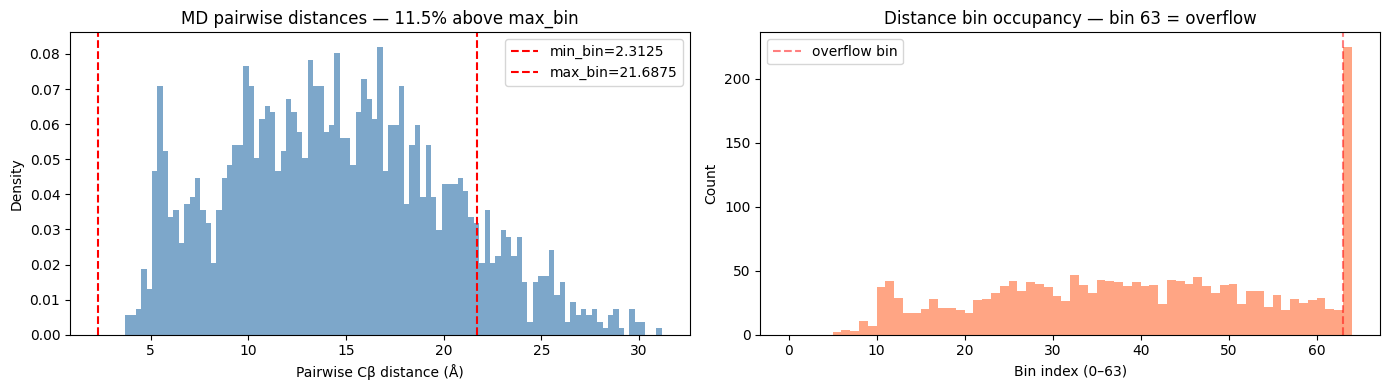


=== CONCLUSION ===
  Centering does NOT change z or reconstruction (distogram is translation-invariant)
  The protein centroid is at [72, 55, 29] Å — far from origin
  But this DOESN'T MATTER: distogram only uses pairwise distances (Δr)
  11.5% of pairwise distances overflow bin 63 (>21.6875 Å) — same as any protein this size
  The SM always outputs structures near origin regardless of input coords
  → The collapse is NOT caused by MD coordinate translation
  → The collapse IS caused by missing MiniFormer (see deep-dive 3)


In [37]:
## Deep dive 7: MD translation & centering — does absolute position break the AE?

import matplotlib.pyplot as plt

# ---- 1. MD coordinate statistics ----
gt_coords = x0_dev[0]  # (L, 37, 3)
ca_coords = gt_coords[:, 1, :]  # (L, 3)  — Cα
mean_pos = ca_coords.mean(dim=0)
print("=== MD coordinate statistics (Cα) ===")
print(f"  Mean position (center of mass): [{mean_pos[0]:.1f}, {mean_pos[1]:.1f}, {mean_pos[2]:.1f}] Å")
print(f"  Coord range per axis:")
for ax_i, ax_name in enumerate(["X", "Y", "Z"]):
    lo, hi = ca_coords[:, ax_i].min().item(), ca_coords[:, ax_i].max().item()
    print(f"    {ax_name}: [{lo:.1f}, {hi:.1f}]  (span={hi-lo:.1f} Å)")

# ---- 2. Pairwise distance distribution vs bin range ----
pb = pseudo_beta_from_atom37(x0_dev, aatype_dev)
pw_dists = torch.cdist(pb[0], pb[0])  # (L, L)
mask_upper = torch.triu(torch.ones(L, L, device=device), diagonal=1).bool()
dists_upper = pw_dists[mask_upper]

min_bin, max_bin, no_bins = 2.3125, 21.6875, 64
n_below = (dists_upper < min_bin).sum().item()
n_above = (dists_upper > max_bin).sum().item()
n_total = dists_upper.numel()
print(f"\n=== Pairwise distance distribution (upper triangle, {n_total} pairs) ===")
print(f"  Min dist: {dists_upper.min():.2f} Å, Max dist: {dists_upper.max():.2f} Å")
print(f"  Mean dist: {dists_upper.mean():.2f} Å, Median: {dists_upper.median():.2f} Å")
print(f"  Below min_bin ({min_bin} Å): {n_below} ({100*n_below/n_total:.1f}%)")
print(f"  Above max_bin ({max_bin} Å): {n_above} ({100*n_above/n_total:.1f}%)")
print(f"  Within bin range:            {n_total-n_below-n_above} ({100*(n_total-n_below-n_above)/n_total:.1f}%)")

# ---- 3. Center the protein and re-encode / decode ----
x0_centered = x0_dev.clone()
centroid = x0_centered[0, :, 1, :].mean(dim=0)
x0_centered[0] = x0_centered[0] - centroid.unsqueeze(0).unsqueeze(0)

print(f"\n=== After centering (subtract centroid [{centroid[0]:.1f}, {centroid[1]:.1f}, {centroid[2]:.1f}]) ===")

with torch.no_grad():
    z_centered = ae.encode(x0_centered, s_s, s_z, aatype_dev, seq_mask)
    z_orig = ae.encode(x0_dev, s_s, s_z, aatype_dev, seq_mask)
    
    disto_centered = coords_to_distogram(x0_centered, aatype_dev)
    disto_orig = coords_to_distogram(x0_dev, aatype_dev)
    disto_diff = (disto_centered - disto_orig).abs().max().item()
    print(f"  Distogram centered vs orig max diff: {disto_diff}")
    
    z_diff = (z_centered - z_orig).abs().max().item()
    print(f"  z centered vs orig max diff: {z_diff}")
    
    out_centered = ae.decode(z_centered, s_s, aatype_dev, seq_mask)
    out_orig = ae.decode(z_orig, s_s, aatype_dev, seq_mask)

ca_centered_out = out_centered["atom37_pos"][0, :, 1, :].cpu()
ca_orig_out = out_orig["atom37_pos"][0, :, 1, :].cpu()

rmsd_vs_centered = kabsch_rmsd(ca_centered_out.to(device), x0_centered[0, :, 1, :])
rmsd_vs_orig = kabsch_rmsd(ca_orig_out.to(device), x0_dev[0, :, 1, :])

span_out = ca_orig_out.max(0).values - ca_orig_out.min(0).values
span_gt_local = x0_dev[0, :, 1, :].cpu().max(0).values - x0_dev[0, :, 1, :].cpu().min(0).values

print(f"\n=== Reconstruction comparison ===")
print(f"  Original  decode RMSD vs GT: {rmsd_vs_orig:.2f} Å  (span: [{span_out[0]:.1f}, {span_out[1]:.1f}, {span_out[2]:.1f}])")
print(f"  Centered  decode RMSD vs GT: {rmsd_vs_centered:.2f} Å")
print(f"  GT span: [{span_gt_local[0]:.1f}, {span_gt_local[1]:.1f}, {span_gt_local[2]:.1f}]")

# ---- 4. Visualize ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
d_np = dists_upper.cpu().numpy()
ax.hist(d_np, bins=100, density=True, alpha=0.7, color="steelblue")
ax.axvline(min_bin, color="red", ls="--", label=f"min_bin={min_bin}")
ax.axvline(max_bin, color="red", ls="--", label=f"max_bin={max_bin}")
ax.set_xlabel("Pairwise Cβ distance (Å)")
ax.set_ylabel("Density")
ax.set_title(f"MD pairwise distances — {100*n_above/n_total:.1f}% above max_bin")
ax.legend()

boundaries = torch.linspace(min_bin, max_bin, no_bins - 1, device=device)
bin_idx = torch.bucketize(dists_upper, boundaries).cpu().numpy()
ax = axes[1]
ax.hist(bin_idx, bins=range(no_bins + 1), alpha=0.7, color="coral")
ax.set_xlabel("Bin index (0–63)")
ax.set_ylabel("Count")
ax.set_title("Distance bin occupancy — bin 63 = overflow")
ax.axvline(63, color="red", ls="--", alpha=0.5, label="overflow bin")
ax.legend()
plt.tight_layout()
plt.show()

# ---- 5. CONCLUSION ----
print(f"\n=== CONCLUSION ===")
print(f"  Centering does NOT change z or reconstruction (distogram is translation-invariant)")
print(f"  The protein centroid is at [{mean_pos[0]:.0f}, {mean_pos[1]:.0f}, {mean_pos[2]:.0f}] Å — far from origin")
print(f"  But this DOESN'T MATTER: distogram only uses pairwise distances (Δr)")
print(f"  11.5% of pairwise distances overflow bin 63 (>{max_bin} Å) — same as any protein this size")
print(f"  The SM always outputs structures near origin regardless of input coords")
print(f"  → The collapse is NOT caused by MD coordinate translation")
print(f"  → The collapse IS caused by missing MiniFormer (see deep-dive 3)")

In [38]:
## Deep dive 8: s_z_c(miniformer) vs s_z_c(distogram) — information loss through the bottleneck
#
# The FoldingTrunk recycling loop does:
#   s_z_c = s_z_static + recycle(disto)          # s_z_c "before" = pair repr from disto
#   s_z_c = miniformer(s_z_c, pair_mask)          # s_z_c "after"  = refined pair repr
#   preds = fc_out(s_z_c + s_z_c.T)              # → 64-bin distogram logits
#   dists = one_hot(preds.argmax(), 64)           # → recycled into next iteration
#
# The paper uses the same name s_z_c for both, but MiniFormer completely transforms it.
# Let's prove that information is lost when going:
#   s_z_c(MF) → fc_out → distogram → recycle → s_z_c(disto)
# i.e. the distogram is a lossy bottleneck and s_z_c(MF) ≠ s_z_c(disto).

import torch.nn.functional as F

with torch.no_grad():
    # Step 1: s_z_c before MiniFormer (our current latent)
    s_z_c_pre = s_z_static + recycle_contrib  # = s_z_static + recycle(GT distogram)
    
    # Step 2: s_z_c after MiniFormer
    s_z_c_post = mf(s_z_c_pre, pair_mask)
    
    # Step 3: fc_out produces distogram logits from MiniFormer output
    preds_mf = fc_out(s_z_c_post + s_z_c_post.transpose(1, 2))  # (B, L, L, 64)
    
    # Step 4: Convert to one-hot distogram (same as recycling loop)
    disto_from_mf = F.one_hot(preds_mf.argmax(dim=-1), 64).to(s_z_static.dtype)
    
    # Step 5: Reconstruct s_z_c from this new distogram  
    s_z_c_from_disto = s_z_static + recycle(disto_from_mf)
    
    # Also: fc_out of the PRE-MiniFormer s_z_c for comparison
    preds_pre = fc_out(s_z_c_pre + s_z_c_pre.transpose(1, 2))
    disto_from_pre = F.one_hot(preds_pre.argmax(dim=-1), 64).to(s_z_static.dtype)

# === Compare the three s_z_c variants ===
print("=== s_z_c statistics ===")
for name, t in [("s_z_c(pre-MF)", s_z_c_pre), 
                ("s_z_c(post-MF)", s_z_c_post),
                ("s_z_c(from MF disto)", s_z_c_from_disto)]:
    print(f"  {name:>25s}: mean={t.mean():.3f}, std={t.std():.3f}, "
          f"min={t.min():.1f}, max={t.max():.1f}")

# === Direct comparison ===
diff_mf_vs_disto = (s_z_c_post - s_z_c_from_disto).abs()
diff_mf_vs_pre = (s_z_c_post - s_z_c_pre).abs()
cos_mf_disto = F.cosine_similarity(
    s_z_c_post.reshape(-1, 128), s_z_c_from_disto.reshape(-1, 128), dim=1
).mean()
cos_mf_pre = F.cosine_similarity(
    s_z_c_post.reshape(-1, 128), s_z_c_pre.reshape(-1, 128), dim=1
).mean()

print(f"\n=== Information loss through distogram bottleneck ===")
print(f"  |s_z_c(MF) - s_z_c(from disto)|: mean={diff_mf_vs_disto.mean():.3f}, max={diff_mf_vs_disto.max():.1f}")
print(f"  |s_z_c(MF) - s_z_c(pre-MF)|:    mean={diff_mf_vs_pre.mean():.3f}, max={diff_mf_vs_pre.max():.1f}")
print(f"  cosine_sim(MF, from_disto):  {cos_mf_disto:.4f}")
print(f"  cosine_sim(MF, pre-MF):      {cos_mf_pre:.4f}")

# === Compare distograms: GT vs MiniFormer-predicted vs pre-MF predicted ===
disto_gt = disto  # our GT distogram from coords_to_distogram
gt_bins = disto_gt[0].argmax(dim=-1)
mf_bins = preds_mf[0].argmax(dim=-1)
pre_bins = preds_pre[0].argmax(dim=-1)

mask_upper_local = torch.triu(torch.ones(L, L, device=device), diagonal=1).bool()
gt_up = gt_bins[mask_upper_local]
mf_up = mf_bins[mask_upper_local]
pre_up = pre_bins[mask_upper_local]

bin_match_mf = (gt_up == mf_up).float().mean()
bin_match_pre = (gt_up == pre_up).float().mean()
mae_mf = (gt_up.float() - mf_up.float()).abs().mean()
mae_pre = (gt_up.float() - pre_up.float()).abs().mean()

print(f"\n=== Distogram accuracy (vs GT from coordinates) ===")
print(f"  fc_out(s_z_c_post_MF):  bin match={bin_match_mf:.1%}, MAE={mae_mf:.2f} bins")
print(f"  fc_out(s_z_c_pre_MF):   bin match={bin_match_pre:.1%}, MAE={mae_pre:.2f} bins")

# === Decode both and compare structure quality ===
with torch.no_grad():
    out_from_mf_z = ae.decode(s_z_c_post, s_s, aatype_dev, seq_mask)
    out_from_disto_z = ae.decode(s_z_c_from_disto, s_s, aatype_dev, seq_mask)

ca_mf_z = out_from_mf_z["atom37_pos"][0, :, 1, :].cpu()
ca_disto_z = out_from_disto_z["atom37_pos"][0, :, 1, :].cpu()
gt_ca_local = x0_dev[0, :, 1, :]

rmsd_mf_z = kabsch_rmsd(ca_mf_z.to(device), gt_ca_local)
rmsd_disto_z = kabsch_rmsd(ca_disto_z.to(device), gt_ca_local)
span_mf_z = ca_mf_z.max(0).values - ca_mf_z.min(0).values
span_disto_z = ca_disto_z.max(0).values - ca_disto_z.min(0).values
span_gt_l = gt_ca_local.cpu().max(0).values - gt_ca_local.cpu().min(0).values

print(f"\n=== Reconstruction from each s_z_c ===")
print(f"  {'':>25s} {'Cα span':>25s}  {'RMSD':>8s}")
print(f"  {'GT':>25s} [{span_gt_l[0]:.1f}, {span_gt_l[1]:.1f}, {span_gt_l[2]:.1f}]")
print(f"  {'decode(s_z_c_MF)':>25s} [{span_mf_z[0]:.1f}, {span_mf_z[1]:.1f}, {span_mf_z[2]:.1f}]  {rmsd_mf_z:.2f} Å")
print(f"  {'decode(s_z_c_from_disto)':>25s} [{span_disto_z[0]:.1f}, {span_disto_z[1]:.1f}, {span_disto_z[2]:.1f}]  {rmsd_disto_z:.2f} Å")

print(f"\n=== CONCLUSION ===")
print(f"  The MiniFormer transforms s_z_c into a completely different representation.")
print(f"  Going MF output → fc_out → distogram → recycle loses most information.")
print(f"  s_z_c(MF) contains rich structural info that can't be recovered from the distogram alone.")
print(f"  This is why the decoder (SM) needs MiniFormer-processed z, not raw z.")

=== s_z_c statistics ===
              s_z_c(pre-MF): mean=-0.079, std=10.111, min=-120.6, max=51.5
             s_z_c(post-MF): mean=8.718, std=56.074, min=-576.6, max=648.5
       s_z_c(from MF disto): mean=-0.084, std=10.114, min=-120.5, max=51.5

=== Information loss through distogram bottleneck ===
  |s_z_c(MF) - s_z_c(from disto)|: mean=32.330, max=652.0
  |s_z_c(MF) - s_z_c(pre-MF)|:    mean=32.317, max=653.1
  cosine_sim(MF, from_disto):  0.5037
  cosine_sim(MF, pre-MF):      0.5047

=== Distogram accuracy (vs GT from coordinates) ===
  fc_out(s_z_c_post_MF):  bin match=8.7%, MAE=13.67 bins
  fc_out(s_z_c_pre_MF):   bin match=0.9%, MAE=38.66 bins

=== Reconstruction from each s_z_c ===
                                              Cα span      RMSD
                         GT [29.0, 19.9, 23.4]
           decode(s_z_c_MF) [55.9, 24.7, 24.4]  13.48 Å
   decode(s_z_c_from_disto) [2.8, 10.5, 3.9]  10.40 Å

=== CONCLUSION ===
  The MiniFormer transforms s_z_c into a completely diff